In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

### Predicting Daily Biogas Production Using Machine Learning

## 1. Research problem
### 1.1. Background

Biogas production from organic waste plays an important role in sustainable energy generation and waste management. The ability to accurately predict daily biogas output enables better planning of energy supply and optimization of the anaerobic digestion process. This project uses a 15-year representing dataset from a biogas plant in India to develop regression models capable of predicting daily biogas production and supporting operational decision-making in similar facilities.

### 1.2 Business Perspective

Can daily biogas production (m³) be predicted from feedstock composition, operational parameters, and environmental conditions with sufficient accuracy to support the operation and planning of a biogas plant?

For a biogas plant, predicting production with a 10% error margin is generally acceptable because gas storage buffers absorb daily fluctuations. According to the literature, gasholders are designed as buffer devices that adjust peaks and fluctuations in biogas production.<sup>[1]</sup>, with typical storage capacities ranging from 10-30% of daily production for continuously operating systems. A prediction error of 10% falls into this range, meaning the plant can absorb such a deviation without operational disturbance.

### 1.3 Data Science Perspective
The goal is to build a regression model that predicts the continuous target variable, Raw Biogas Produced (m³), using the 22 scalar features available in the dataset. The model's performance will be evaluated based on two primary metrics:

R²: The model will be considered successful if it achieves an R² score greater than 0.75, indicating that it explains the majority of the variance in biogas production.

RMSE: The model will be considered successful if its RMSE is less than 10% of the mean daily biogas production, ensuring that prediction errors are small relative to the typical output of the plant.

### 1.4 Hypothesis
**Null hypothesis (H₀):** The available input variables (waste composition, operational parameters, and weather conditions) do not provide meaningful predictive information about daily biogas production. Any prediction model will perform no better than a simple baseline using the average daily production.

**Alternative hypothesis (H₁):** Feedstock quantities, biological process parameters, and environmental conditions are associated with daily biogas production. Specifically, higher quantities of organic feedstock and favorable digestion conditions are expected to increase biogas production. A regression model trained on these variables will significantly outperform a baseline model.

A regression model trained on these variables will significantly outperform a baseline model. 
We expect:

* Models using waste composition, operational parameters, and weather conditions to outperform a baseline model.
* Waste quantity variables to show a positive relationship with biogas production.
* Feature importance analysis to identify waste composition as one of the key drivers of production.

The hypothesis will be considered supported if:

* the final model achieves R² ≥ 0.75;
* RMSE remains below 10% of the mean daily production;
* models including waste-related features perform substantially better than models using weather variables alone.

**Summary**:
We expect tree-based ensemble models (Random Forest and Gradient Boosting) to outperform a simple linear regression baseline because biogas production is influenced by multiple interacting process and environmental variables.

## 2. Dataset Overview & Technical Background

### 2.1 Dataset Overview

The dataset contains operational data from a biogas plant, including feedstock quantities, environmental conditions, and process-related variables. No missing values or duplicate records were identified in the dataset. All features are stored as numerical values and are suitable for regression analysis.

### 2.2 Feature Categories

| Category | Examples |

|-----------|----------|

| Feedstock | Pig Manure, Kitchen Food Waste, Chicken Litter, Fish Waste |

| Operational | Water Usage, Diesel Consumption, Electricity Usage |

| Environmental | Temperature, Humidity, Rainfall |

| Process Variables | Digester Temperature, C/N Ratio |

| Target | biogas_production |

### 2.3 Technical Background & Feature Explanation

Based on domain knowledge of anaerobic digestion, several variables in the dataset are known to influence biogas production.:

* Feedstock Composition: Kitchen food waste, Pig manure, Chicken litter
* Volatile solids
* Digester temperature
* Hydraulic retention time (HRT)
* C/N ratio


Based on domain knowledge of anaerobic digestion, several variables in the dataset are known to influence biogas production:

* **Feedstock Composition**: Kitchen food waste, Pig manure, and Chicken litter provide the organic matter that microorganisms convert into biogas. In general, larger quantities of biodegradable material are expected to increase gas production.
* **Volatile Solids (VS)**: Volatile solids represent the biodegradable portion of the feedstock. Since microorganisms consume this organic matter during digestion, higher volatile solids content is generally associated with greater biogas production potential.
* **Digester Temperature**: Microbial activity depends strongly on temperature. Digestion is most efficient within specific temperature ranges, while lower temperatures can reduce gas production by slowing microbial processes.
* **Hydraulic Retention Time (HRT)**: Hydraulic Retention Time measures how long the feedstock remains inside the digester. Longer retention times allow microorganisms more time to break down organic material and produce biogas.
* **Carbon-to-Nitrogen Ratio (C/N Ratio)**: The C/N ratio describes the balance between carbon and nitrogen in the feedstock. An appropriate balance supports microbial growth and efficient digestion, while an imbalance may reduce biogas yield. <sup>[2]</sup>

## 3. Dataset Structure


In [2]:
biogas_data = pd.read_csv('biogas_dataset.csv')
biogas_data.shape
biogas_data.head()
biogas_data.info()
biogas_data.dtypes


<class 'pandas.DataFrame'>
RangeIndex: 15298 entries, 0 to 15297
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     15298 non-null  int64  
 1   Month                    15298 non-null  int64  
 2   Day                      15298 non-null  int64  
 3   Pig Manure (kg)          15298 non-null  float64
 4   Kitchen Food Waste (kg)  15298 non-null  float64
 5   Chicken Litter (kg)      15298 non-null  float64
 6   Cassava (kg)             15298 non-null  float64
 7   Bagasse Feed (kg)        15298 non-null  float64
 8   Energy Grass (kg)        15298 non-null  float64
 9   Banana Shafts (kg)       15298 non-null  float64
 10  Alcohol Waste (kg)       15298 non-null  float64
 11  Municipal Residue (kg)   15298 non-null  float64
 12  Fish Waste (kg)          15298 non-null  float64
 13  Water (L)                15298 non-null  float64
 14  Diesel (L)               15298 no

Year                         int64
Month                        int64
Day                          int64
Pig Manure (kg)            float64
Kitchen Food Waste (kg)    float64
Chicken Litter (kg)        float64
Cassava (kg)               float64
Bagasse Feed (kg)          float64
Energy Grass (kg)          float64
Banana Shafts (kg)         float64
Alcohol Waste (kg)         float64
Municipal Residue (kg)     float64
Fish Waste (kg)            float64
Water (L)                  float64
Diesel (L)                 float64
Electricity Use (kWh)      float64
Temperature (C)            float64
Humidity (%)               float64
Rainfall (mm)              float64
C/N Ratio                  float64
Digester Temp (C)          float64
biogas_production          float64
dtype: object

### Summary of initial observations

Dataset contains 15,298 observations. All variables are numerical (`int64` or `float64`). No categorical variables are present. The target variable is `biogas_production`.

# 4. Data Quality Assessment

In [3]:
print(biogas_data.isnull().sum())
print(f"Duplicates: {biogas_data.duplicated().sum()}")

Year                       0
Month                      0
Day                        0
Pig Manure (kg)            0
Kitchen Food Waste (kg)    0
Chicken Litter (kg)        0
Cassava (kg)               0
Bagasse Feed (kg)          0
Energy Grass (kg)          0
Banana Shafts (kg)         0
Alcohol Waste (kg)         0
Municipal Residue (kg)     0
Fish Waste (kg)            0
Water (L)                  0
Diesel (L)                 0
Electricity Use (kWh)      0
Temperature (C)            0
Humidity (%)               0
Rainfall (mm)              0
C/N Ratio                  0
Digester Temp (C)          0
biogas_production          0
dtype: int64
Duplicates: 0


In [4]:
biogas_data.dtypes

Year                         int64
Month                        int64
Day                          int64
Pig Manure (kg)            float64
Kitchen Food Waste (kg)    float64
Chicken Litter (kg)        float64
Cassava (kg)               float64
Bagasse Feed (kg)          float64
Energy Grass (kg)          float64
Banana Shafts (kg)         float64
Alcohol Waste (kg)         float64
Municipal Residue (kg)     float64
Fish Waste (kg)            float64
Water (L)                  float64
Diesel (L)                 float64
Electricity Use (kWh)      float64
Temperature (C)            float64
Humidity (%)               float64
Rainfall (mm)              float64
C/N Ratio                  float64
Digester Temp (C)          float64
biogas_production          float64
dtype: object

### Findings
No missing values or duplicate records were identified in the dataset. All features are stored as numerical values and are suitable for regression analysis.
No categorical features are present, therefore no encoding techniques are required.

# 5. Exploratory Data Analysis (EDA)

## 5.1 Summary Statistics



In [5]:
biogas_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,15298.0,2016.999477,4.320433,2010.000000,2013.000000,2017.000000,2021.000000,2024.000000
Month,15298.0,6.521571,3.448833,1.000000,4.000000,7.000000,10.000000,12.000000
Day,15298.0,15.723101,8.799470,1.000000,8.000000,16.000000,23.000000,31.000000
Pig Manure (kg),15298.0,25.097493,9.869836,0.103366,18.270828,25.007929,31.805712,60.711466
Kitchen Food Waste (kg),15298.0,17.945933,6.975865,0.002521,13.181458,17.880665,22.611847,47.323544
Chicken Litter (kg),15298.0,12.014503,4.912169,0.001158,8.633978,12.002030,15.279068,31.294118
Cassava (kg),15298.0,20.034405,7.938863,0.001361,14.561289,20.081747,25.349684,49.149914
Bagasse Feed (kg),15298.0,15.087888,5.969113,0.007269,11.026886,15.124088,19.187529,38.563105
Energy Grass (kg),15298.0,10.037762,3.941196,0.011412,7.368683,10.037847,12.695036,25.423541
Banana Shafts (kg),15298.0,8.012272,3.006955,0.004688,5.968436,8.004483,10.047839,21.421714


In [6]:
biogas_data['biogas_production'].skew()

np.float64(0.18553199353932806)

The dataset contains 15,298 daily records with 22 numerical features. All features have complete data (no missing values). The target variable, biogas production, ranges from 41.9 to 121.7 m³ with a mean of 79.2 m³ and a median of 78.8 m³, indicating a relatively symmetric distribution with moderate variability (σ = 11.3 m³).

Feedstock quantities show wide variation: Pig Manure averages 25 kg/day (range: 0-60 kg), Kitchen Food Waste averages 17.9 kg/day (range: 0-47 kg), and Chicken Litter averages 12.8 kg/day (range: 0-31 kg). Environmental conditions are relatively stable, with Temperature averaging 29.9°C (range: 19.2-41.7°C) and Humidity at 75% (range: 33-110%).

The substantial range in feedstock quantities suggests significant operational variability, which likely contributes to the observed variation in biogas production.

Daily biogas production ranged from 41.9 m³ to 121.7 m³, with a mean of 79.2 m³ and a median of 78.8 m³. The small difference between the mean and median, together with a skewness value of 0.19, indicates an approximately symmetric distribution. The interquartile range (71.3–86.7 m³) shows that most observations are concentrated around the central tendency, suggesting relatively stable production levels with no obvious extreme anomalies.

As we can see features have different scales, from which we can make a conclusion that we need scaling for linear models.

### 5.2. Distribution and outliers investigation


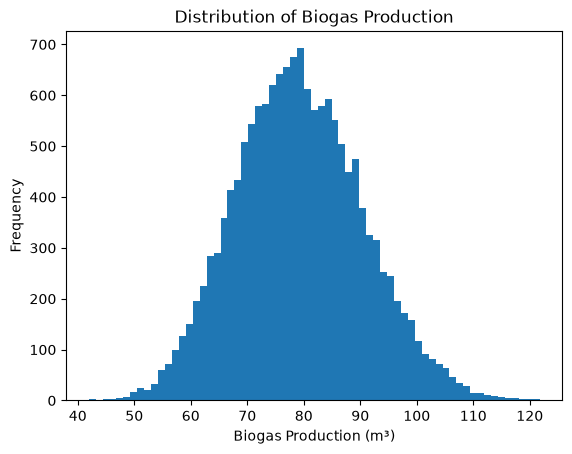

In [7]:
plt.hist(biogas_data["biogas_production"], bins="fd")
plt.title("Distribution of Biogas Production")
plt.xlabel("Biogas Production (m³)")
plt.ylabel("Frequency")
plt.show()

The distribution of daily biogas production appears  bell-shaped with a single peak no strong skewness (skewness is approximately 0.19, indicating only slight positive skewness. This suggests a relatively stable production process without obvious subgroups or extreme asymmetry in the target variable.


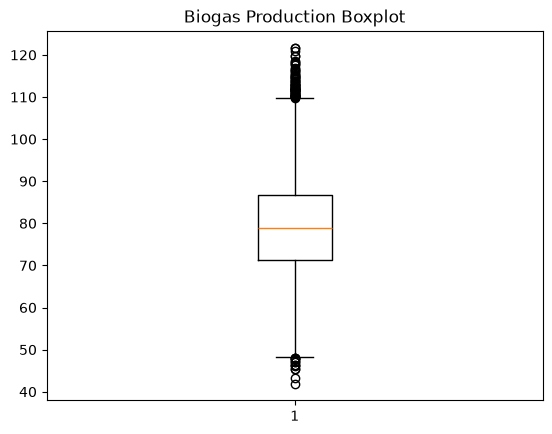

In [8]:
plt.boxplot(biogas_data["biogas_production"])
plt.title("Biogas Production Boxplot")
plt.show()

The boxplot indicates the presence of several observations outside the interquartile range boundaries. These values may represent unusually high or low production days. Since they may correspond to genuine operational conditions rather than data errors, no observations were removed at this stage.

In [9]:
Q1 = biogas_data["biogas_production"].quantile(0.25)
Q3 = biogas_data["biogas_production"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = biogas_data[
    (biogas_data["biogas_production"] < lower) |
    (biogas_data["biogas_production"] > upper)
]

print(len(outliers))

83


There is 83 outliers out of 15,298 rows. This can be interpritated as most production days behave similarly, while a small number of days show unusually low or high production.

### 5.3. Relationship Between Key Features and Biogas Production

#### Kitchen Food Waste vs Biogas Production

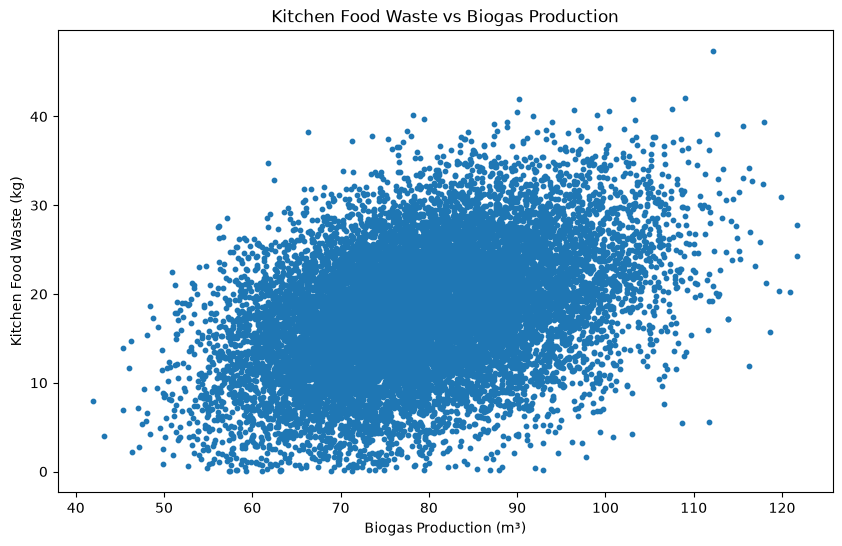

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(biogas_data["biogas_production"], 
            biogas_data["Kitchen Food Waste (kg)"], 
            s=10)
plt.xlabel("Biogas Production (m³)")
plt.ylabel("Kitchen Food Waste (kg)")
plt.title("Kitchen Food Waste vs Biogas Production")
plt.show()

The scatter plot for Kitchen Food Waste shows a moderate positive relationship with biogas production (correlation coefficient of 0.407 - can be seen in the table below all plots). While it clearly contributes to the biogas yield, the relationship is not as strong or strictly linear as that of Pig Manure. The data points are more dispersed, indicating that while it is a valuable feedstock, its individual daily impact is less predictable than pig manure.

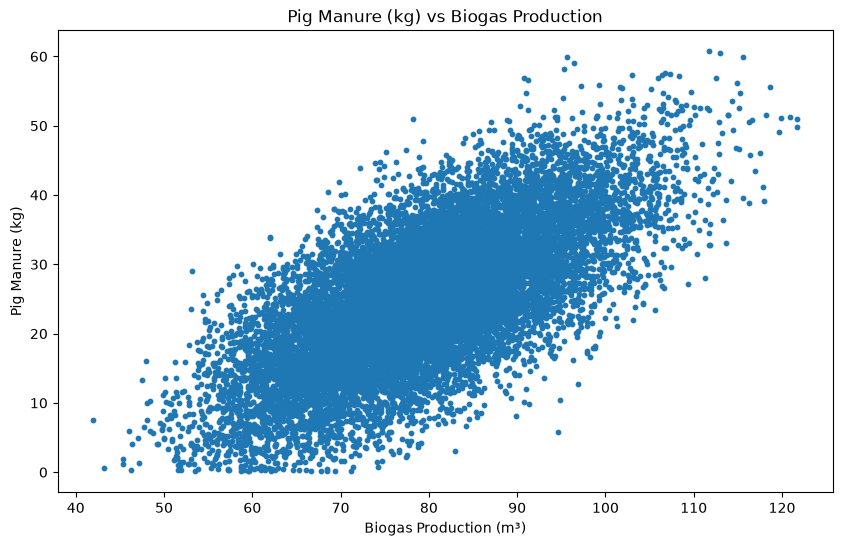

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(biogas_data["biogas_production"], 
            biogas_data["Pig Manure (kg)"], 
             s=10)
plt.xlabel("Biogas Production (m³)")
plt.ylabel("Pig Manure (kg)")
plt.title("Pig Manure (kg) vs Biogas Production")
plt.show()

The scatter plot of Pig Manure versus biogas production shows a clear positive trend. The Pearson correlation coefficient of 0.695 indicates a strong positive linear relationship. This suggests that the quantity of pig manure is a highly significant and dominant predictor of daily biogas production, with higher quantities consistently corresponding to higher gas yields.

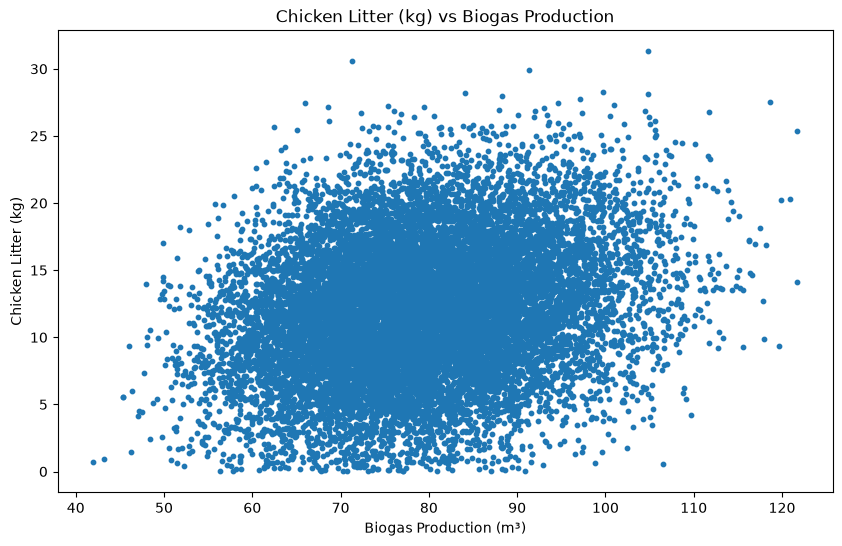

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(biogas_data["biogas_production"], 
            biogas_data["Chicken Litter (kg)"], 
             s=10)
plt.xlabel("Biogas Production (m³)")
plt.ylabel("Chicken Litter (kg)")
plt.title("Chicken Litter (kg) vs Biogas Production")
plt.show()

The scatter plots for Chicken Litter (r = 0.249) show weak to moderate positive correlations. The scatter plots show a general upward trend but with significant variance. This indicates that while these feedstocks contribute to the anaerobic digestion process, their individual daily contributions are less dominant and more variable compared to Pig Manure.

In [13]:
corr = (biogas_data.corr(numeric_only=True)["biogas_production"].sort_values(ascending=False))
print(corr)

biogas_production          1.000000
Pig Manure (kg)            0.695072
Kitchen Food Waste (kg)    0.407208
Cassava (kg)               0.342333
Municipal Residue (kg)     0.272619
Chicken Litter (kg)        0.249052
Bagasse Feed (kg)          0.216974
Water (L)                  0.138231
Temperature (C)            0.122816
Energy Grass (kg)          0.092863
Fish Waste (kg)            0.073418
Alcohol Waste (kg)         0.047514
Banana Shafts (kg)         0.045427
Electricity Use (kWh)      0.016916
Diesel (L)                 0.012036
Month                      0.007012
Rainfall (mm)              0.003375
C/N Ratio                 -0.002593
Digester Temp (C)         -0.004840
Year                      -0.007930
Humidity (%)              -0.009982
Day                       -0.010809
Name: biogas_production, dtype: float64


Correlation analysis conclusion

Correlation analysis revealed that Pig Manure exhibited the strongest positive relationship with biogas production (r = 0.695). Kitchen Food Waste (r = 0.407) and Cassava (r = 0.342) showed moderate positive associations. Several variables, including Humidity, Digester Temperature, and C/N Ratio, displayed correlations close to zero, indicating little evidence of a linear relationship with biogas production. However, low correlation values do not necessarily imply that a variable is unimportant, as nonlinear relationships may still exist.

This way we can see that Pig Manure looks like the dominant predictor in this dataset, much more than Chicken Litter or Kitchen Food Waste.

### 5.4. Temporal Analysis: Is Time a Factor?
Before splitting the data into training, validation, and test sets, it is important to verify that the data is collected consistently over time. If certain time periods were over- or under-represented, or if there were significant trends in biogas production over the 15-year period, a chronological split might be necessary to avoid data leakage and ensure a realistic evaluation.

To assess this, we examine the distribution of records across years, months, and days, as well as the stability of average biogas production over time.

In [14]:
biogas_data["Month"].value_counts().sort_index()

Month
1     1300
2     1184
3     1298
4     1257
5     1297
6     1256
7     1300
8     1299
9     1256
10    1298
11    1256
12    1297
Name: count, dtype: int64

In [15]:
biogas_data["Year"].value_counts().sort_index()

Year
2010    1020
2011    1019
2012    1022
2013    1019
2014    1019
2015    1020
2016    1022
2017    1019
2018    1019
2019    1019
2020    1023
2021    1019
2022    1019
2023    1019
2024    1020
Name: count, dtype: int64

In [16]:
biogas_data["Day"].value_counts().sort_index()

Day
1     504
2     507
3     496
4     511
5     496
6     504
7     503
8     503
9     501
10    508
11    497
12    506
13    500
14    503
15    501
16    507
17    501
18    503
19    502
20    502
21    501
22    504
23    504
24    503
25    502
26    502
27    502
28    505
29    471
30    460
31    289
Name: count, dtype: int64

In [17]:
years = biogas_data.groupby('Year')['biogas_production'].mean()
print("Average biogas by year:")
print(years)

Average biogas by year:
Year
2010    79.559753
2011    79.429558
2012    79.376628
2013    79.184270
2014    79.442158
2015    79.062364
2016    79.191778
2017    79.278391
2018    78.939261
2019    78.859438
2020    78.902621
2021    79.273738
2022    78.929998
2023    79.289642
2024    79.446653
Name: biogas_production, dtype: float64


**Findings**

**Year:** The value_counts() show that there are approximately 1,019-1,023 records for every year. This indicates that the data is collected consistently and without significant gaps over the 15-year period. Furthermore, the mean biogas production across all years is stable, ranging only from 78.9 to 79.6 m³. The maximum difference between the highest and lowest yearly average is a mere 0.7 m³. This confirms the production process is stable and not trending significantly up or down.

**Month:** The value_counts() show that there are approximately 1,250-1,300 records for every month. This indicates the data is evenly distributed across the year, with no single month being significantly over- or under-represented.

**Day:** The value_counts() show that there are approximately 490-510 records for days 1 through 28, with slightly fewer records for days 29, 30, and 31 (ranging from 289 to 471). This is expected, as not all months have 29, 30, or 31 days. This indicates that the data collection is consistent and evenly distributed across the days of the month.

**Correlations:** The near-zero correlations between the temporal features (Year, Month, Day) and biogas production (|r| < 0.011) provide strong statistical evidence that these features are independent of the target variable.

**Conclusion**
The temporal analysis confirms that the data is collected consistently and evenly across all time periods. There are no significant trends, seasonal biases, or gaps in the data that would require a chronological split. Therefore, a random 80/20 train-test split is appropriate for this dataset, as it will not introduce data leakage.

# 6. Preprocessing

## Planned Steps
- Target Variable Separation
- Train/Test Split
- Feature Scaling (if required)

Since the dataset contains no missing values, duplicates, or categorical variables, preprocessing requirements are minimal.

Also the analysis has showen near-zero correlation between temporal features (Year, Month, Day) and biogas production (|r| < 0.011), we used random 80/20 train-test split. The temporal stability of the data (yearly means ranging only 78.9-79.6 m³) suggests that chronological ordering does not significantly affect the prediction task.

### 6.1 Target variable separation

First, we separate the target variable (`biogas_production`) from the feature variables.

In [18]:
biogas_data_attributes = biogas_data.drop(columns = ["biogas_production"])
biogas_data_target = biogas_data.biogas_production

### 6.2 Train/Validation/Test Split

The dataset is split into training (64%), validation (16%), and test (20%) sets. The 64/16/20 split provides sufficient data for training while maintaining a good size for validation and test set for evaluation.

Based on the temporal analysis in Section 4.5, which confirmed that the data is collected consistently across all time periods (yearly means ranging only 78.9-79.6 m³, near-zero correlations with temporal features), a random split is appropriate and will not introduce data leakage.

In [19]:
biogas_data_attributes_train, biogas_data_attributes_test, biogas_data_target_train, biogas_data_target_test = train_test_split(
    biogas_data_attributes, biogas_data_target, test_size=0.2, random_state=42
)
biogas_data_attributes_train, biogas_data_attributes_val, biogas_data_target_train, biogas_data_target_val = train_test_split(biogas_data_attributes_train, biogas_data_target_train, test_size=0.2, random_state=42)

print(f"Training:   {biogas_data_attributes_train.shape}, Target: {biogas_data_target_train.shape}")
print(f"Validation: {biogas_data_attributes_val.shape}, Target: {biogas_data_target_val.shape}")
print(f"Test:       {biogas_data_attributes_test.shape}, Target: {biogas_data_target_test.shape}")

Training:   (9790, 21), Target: (9790,)
Validation: (2448, 21), Target: (2448,)
Test:       (3060, 21), Target: (3060,)


### 6.3 Verifying split representativeness
To ensure the random split did not introduce bias, we compare the target variable statistics across the three sets.

In [20]:
print("Training set:")
print(f"  Biogas mean: {biogas_data_target_train.mean():.2f}")
print(f"  Biogas std:  {biogas_data_target_train.std():.2f}")

print("Validation set:")
print(f"  Biogas mean: {biogas_data_target_val.mean():.2f}")
print(f"  Biogas std:  {biogas_data_target_val.std():.2f}")

print("Test set:")
print(f"  Biogas mean: {biogas_data_target_test.mean():.2f}")
print(f"  Biogas std:  {biogas_data_target_test.std():.2f}")

Training set:
  Biogas mean: 79.23
  Biogas std:  11.25

Validation set:
  Biogas mean: 79.13
  Biogas std:  11.44

Test set:
  Biogas mean: 79.20
  Biogas std:  11.13


All three means are very close to ~79.2, confirming the random split worked good enough.

### 6.4 Feature Scaling
The features can have vastly different scales. That's because:

Pig Manure (kg): ranges from 0 to 5000
C/N Ratio: ranges from 0 to 30
Temperature (C): ranges from 10 to 40

In linear regression, features on different scales can cause unstable gradient descent and misleading coefficient interpretations. To address this, we apply StandardScaler, which standardizes each feature to have a mean of 0 and a standard deviation of 1. 

In [21]:
scaler = StandardScaler()
biogas_data_attributes_train_scaled = scaler.fit_transform(biogas_data_attributes_train)
biogas_data_attributes_val_scaled = scaler.transform(biogas_data_attributes_val)
biogas_data_attributes_test_scaled = scaler.transform(biogas_data_attributes_test)

### 6.5 Outlier Impact Analysis

The boxplot in Section 5.2 identified 83 observations outside the interquartile range boundaries, representing approximately 0.54% of the dataset. These values may represent unusually high or low production days. Before proceeding with modeling, it is important to assess whether these outliers significantly influence model performance.

In [22]:
mask_train = ~biogas_data_attributes_train.index.isin(outliers.index)
outliers_train_count = (~mask_train).sum()
biogas_data_attributes_train_no_outliers = biogas_data_attributes_train_scaled[mask_train]
biogas_data_target_train_no_outliers = biogas_data_target_train[mask_train]

# Retrain Linear Regression without outliers
lr_no_outliers = LinearRegression()
lr_no_outliers.fit(biogas_data_attributes_train_no_outliers, biogas_data_target_train_no_outliers)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
print(f"Outliers in training set: {outliers_train_count}")
print(f"Percentage of training set: {outliers_train_count/len(biogas_data_attributes_train)*100:.2f}%")

Outliers in training set: 48
Percentage of training set: 0.49%


We will evaluate this result in the modeling part so we can compare with the results how good the model performed on validation data.

## 7. Modeling

Based on the preprocessing steps completed in Section 5, the dataset is ready for modeling. The outlier analysis concluded that the 83 statistically unusual observations have no measurable impact on model performance (validation R² difference of 0.0000), so all observations are retained.

Three regression models are evaluated:

1. Linear Regression — A simple linear model that serves as a baseline.
2. Random Forest — An ensemble of decision trees that can capture non-linear relationships and interactions.
3. Gradient Boosting — A sequential ensemble method that often achieves high predictive accuracy.

The models are evaluated using validation R², with the best-performing model selected for final testing.

### 7.1 Baseline Model Evaluation

In [40]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (50)': RandomForestRegressor(n_estimators=50, random_state=42),
    'Random Forest (100)': RandomForestRegressor(n_estimators=100, random_state=42),
    'Random Forest (200)': RandomForestRegressor(n_estimators=200, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(biogas_data_attributes_train_scaled, biogas_data_target_train)
    val_score = model.score(biogas_data_attributes_val_scaled, biogas_data_target_val)
    results[name] = { "validation_r2": val_score }

for name, model in models.items():
    scores = cross_val_score(
        model,
        biogas_data_attributes_train_scaled,
        biogas_data_target_train,
        cv=5,
        scoring="r2"
    )
    results[name]["cv_mean"] = scores.mean()
    results[name]["cv_std"] = scores.std()

final_results = pd.DataFrame(results).T
print(final_results)    

                     validation_r2   cv_mean    cv_std
Linear Regression         0.994432  0.994744  0.000333
Random Forest (50)        0.903990  0.896906  0.004883
Random Forest (100)       0.905305  0.899334  0.004927
Random Forest (200)       0.906610  0.900509  0.004901


### 7.2 Cross Validation Results for Linear Regression And Random Forest

5-fold cross-validation was performed to evaluate the robustness of the models across different subsets of the training data. The cross validation was perfomed for LinearRegression and RandomForest's models. Further will be performed also 5-fold cross-validation for Gradient Boosting.

The results, so far, were consistent with the validation scores obtained earlier. Linear Regression achieved the highest mean cross-validation R² (0.9947) with a very small standard deviation (0.0003), indicating stable performance and good generalization. Random Forest models showed lower average performance and slightly bigger variance, although the standard deviations remained relatively small.

### 7.3 Evaluate outliers on validation set

In [41]:
score_with_outliers = results["Linear Regression"]["validation_r2"]  # using results from the cell above
score_without_outliers = lr_no_outliers.score(biogas_data_attributes_val_scaled, biogas_data_target_val)

print(f"Validation R² with outliers:  {score_with_outliers:.4f}")
print(f"Validation R² without outliers: {score_without_outliers:.4f}")
print(f"Difference: {score_with_outliers - score_without_outliers:.4f}")

Validation R² with outliers:  0.9944
Validation R² without outliers: 0.9944
Difference: -0.0000


The boxplot in Section 5.2 identified 83 observations outside the interquartile range boundaries, representing approximately 0.54% of the dataset. Of these, 48 outliers (0.49% of the training set) were present in the training data. Removing these outliers resulted in no measurable change in validation R² (0.9944 vs 0.9944), confirming they do not significantly influence model performance. Therefore, all observations were retained for modeling.


### 7.3 Gradient Boosting
As stated in the hypothesis (Section 1.4), we expected tree-based ensemble models to outperform Linear Regression due to the presumed complex, non-linear relationships in anaerobic digestion. To test this, we evaluate a Gradient Boosting model.

In [42]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(
    biogas_data_attributes_train,
    biogas_data_target_train
)

results["Gradient Boosting"] = {}
results["Gradient Boosting"]["validation_r2"] = gb.score(
    biogas_data_attributes_val,
    biogas_data_target_val
)

scores_gb = cross_val_score(
    GradientBoostingRegressor(random_state=42),
    biogas_data_attributes_train,
    biogas_data_target_train,
    cv=5,
    scoring="r2"
)

results["Gradient Boosting"]["cv_mean"] = scores_gb.mean()
results["Gradient Boosting"]["cv_std"] = scores_gb.std()

final_results = pd.DataFrame(results).T
print(final_results) 


                     validation_r2   cv_mean    cv_std
Linear Regression         0.994432  0.994744  0.000333
Random Forest (50)        0.903990  0.896906  0.004883
Random Forest (100)       0.905305  0.899334  0.004927
Random Forest (200)       0.906610  0.900509  0.004901
Gradient Boosting         0.954575  0.951519  0.002156


### 7.4 Cross Validation Results for Linear Regression, Random Forest and Gradient Boosting

Gradient Boosting also demonstrated consistent performance, maintaining its position as the second best-performing model with a mean R² score of 0.9515 and a low standard deviation (0.0022). Although the Random Forest models achieved lower average R² scores, their relatively small standard deviations indicate stable performance across the folds. Overall, the ranking of the models remained unchanged after cross-validation, providing additional confidence that the observed results were not caused by a favourable validation split.

*Note*: Linear Regression was trained using standardized features because linear models are sensitive to differences in feature scales. In contrast, Gradient Boosting is a tree-based algorithm and does not require feature scaling, since it partitions the data using decision thresholds rather than distance calculations or coefficient optimization. Therefore, using the original (unscaled) features for Gradient Boosting does not negatively affect its performance and is consistent with the theoretical properties of tree-based models.


Result: Gradient Boosting achieved R² = 0.9546, which is strong but still lower than Linear Regression's 0.9944. This suggests the relationships in this dataset are strongly linear, contradicting our initial expectation.

### 7.5 Single-Feature Analysis: Is Pig Manure Sufficient?

In [27]:
biogas_data_attributes_train_single = biogas_data_attributes_train[['Pig Manure (kg)']]
biogas_data_attributes_val_single = biogas_data_attributes_val[['Pig Manure (kg)']]
biogas_data_attributes_test_single = biogas_data_attributes_test[['Pig Manure (kg)']]

# Scale
scaler_single = StandardScaler()
biogas_data_attributes_train_single_scaled = scaler_single.fit_transform(biogas_data_attributes_train_single)
biogas_data_attributes_val_single_scaled = scaler_single.transform(biogas_data_attributes_val_single)
biogas_data_attributes_test_single_scaled = scaler_single.transform(biogas_data_attributes_test_single)

# Train models
lr_single = LinearRegression()
lr_single.fit(biogas_data_attributes_train_single_scaled, biogas_data_target_train)
rf_single = RandomForestRegressor(n_estimators=100, random_state=42)
rf_single.fit(biogas_data_attributes_train_single_scaled, biogas_data_target_train)

print("With ONLY Pig Manure:")
print(f"  Linear Regression Val R²: {lr_single.score(biogas_data_attributes_val_single_scaled, biogas_data_target_val):.4f}")
print(f"  Random Forest Val R²: {rf_single.score(biogas_data_attributes_val_single_scaled, biogas_data_target_val):.4f}")

With ONLY Pig Manure:
  Linear Regression Val R²: 0.4846
  Random Forest Val R²: 0.2628


The single-feature model explains only 48.5% of the variance, confirming that while Pig Manure is the most important predictor, the other 20 features collectively contribute. This means we cannot simplify the model to just Pig Manure - we will loose ~51% of predictive power. This justifies the use of the full feature set.

### 7.6 Feature Impact Analysis

To understand which variables are most influential in predicting biogas production, two complementary analyses were performed:

1. Feature Importance (Random Forest): Measures how much each feature contributes to reducing prediction error in a non-linear model.
2. Coefficient Magnitude (Linear Regression): Measures the linear impact of each feature on the target variable.

#### 7.6.1 Random Forest Feature Importance


In [28]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(biogas_data_attributes_train_scaled, biogas_data_target_train)

importance_df = pd.DataFrame({
    'feature': biogas_data_attributes_train.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (All Features):")
print(importance_df)

Feature Importance (All Features):
                    feature  importance
3           Pig Manure (kg)    0.489981
4   Kitchen Food Waste (kg)    0.159505
6              Cassava (kg)    0.114213
11   Municipal Residue (kg)    0.062760
5       Chicken Litter (kg)    0.056927
7         Bagasse Feed (kg)    0.036436
16          Temperature (C)    0.011301
13                Water (L)    0.011254
8         Energy Grass (kg)    0.007772
12          Fish Waste (kg)    0.006468
9        Banana Shafts (kg)    0.005306
10       Alcohol Waste (kg)    0.004577
15    Electricity Use (kWh)    0.004535
17             Humidity (%)    0.004166
18            Rainfall (mm)    0.004085
19                C/N Ratio    0.004030
14               Diesel (L)    0.004008
20        Digester Temp (C)    0.003964
2                       Day    0.003289
0                      Year    0.002809
1                     Month    0.002614


#### 7.6.2 Linear Regression Coefficients

In [29]:
linear_model = LinearRegression()
linear_model.fit(
    biogas_data_attributes_train_scaled,
    biogas_data_target_train
)
pd.DataFrame({
    "Feature": biogas_data_attributes_train.columns,
    "Coefficient": linear_model.coef_
}).sort_values(
    by="Coefficient",
    key=abs,
    ascending=False
)

,Feature,Coefficient
3,Pig Manure (kg),7.789058
4,Kitchen Food Waste (kg),4.553580
6,Cassava (kg),3.888908
11,Municipal Residue (kg),2.889917
5,Chicken Litter (kg),2.864127
7,Bagasse Feed (kg),2.455603
16,Temperature (C),1.478446
13,Water (L),1.407112
8,Energy Grass (kg),1.088650
12,Fish Waste (kg),0.844259


#### 7.6.3 Interpretation

Both methods consistently identify the same top predictors:

| Feature | RF Importance | LR Coefficient |
|---|---|---|
| Pig Manure (kg) | 0.490 | 7.789 |
| Kitchen Food Waste (kg) | 0.160 | 4.554 |
| Cassava (kg) | 0.114 | 3.889 |
| Municipal Residue (kg) | 0.063 | 2.890 |
| Chicken Litter (kg) | 0.057 | 2.864 |

**Pig Manure** is the dominant predictor in both analyses. The large positive coefficient from Linear Regression (7.789) indicates that increasing pig manure by one standard deviation (approximately 9.87 kg) is associated with an increase of ~7.79 m³ in biogas production. This strong linear relationship, combined with its high feature importance, suggests that pig manure quantity is the most critical operational variable for predicting daily biogas output.

####  8. Model Evaluation & Diagnostics

Contrary to the initial expectation, Linear Regression achieved the highest predictive performance, obtaining a validation R² score of 0.9944. Gradient Boosting also performed strongly (R² = 0.9546), while Random Forest achieved a lower but still substantial score (R² = 0.9066).

These results suggest that the relationships between the predictor variables and biogas production are linear. Although ensemble tree-based methods were able to capture most of the variability in the target variable, they did not improve upon the simpler linear model. Therefore, the initial hypothesis that ensemble models would outperform Linear Regression was not supported by the data.

Since Linear Regression was the best-performing model, it was selected for final evaluation on the test set.

In [30]:
best_model = models[best_name]
test_score = best_model.score(biogas_data_attributes_test_scaled, biogas_data_target_test)
print(f"\n FINAL Test R²: {test_score:.4f}")


 FINAL Test R²: 0.9943


The fact that:  Validation = 0.9944     Test       = 0.9943

The validation set (0.9944) and test set (0.9943) scores being nearly identical primarily indicates that the model generalizes well to unseen data and there is no overfitting.

Now lets finish the job and calculate RMSE.


In [31]:
predictions = best_model.predict(biogas_data_attributes_test_scaled)
rmse = np.sqrt(
    mean_squared_error(
        biogas_data_target_test,
        predictions
    )
)

print(f"Test RMSE: {rmse:.2f}")

Test RMSE: 0.84


Based on everything we've seen, we can conclude that the dataset appears highly predictable, with the dominant predictors being Pig Manure, Kitchen Food Waste, Cassava, Municipal Residue, and Chicken Litter. The relationship between predictors and the target is largely linear, as tree-based ensemble methods did not improve performance over the simpler linear baseline.

The first hypothesis—that a machine learning model can predict daily biogas production with useful accuracy (R² > 0.75)—was strongly supported, with the final model achieving an R² of 0.9943 and an RMSE of 0.84 m³. However, the second hypothesis—that Random Forest and Gradient Boosting would outperform Linear Regression—was not supported, as Linear Regression achieved the highest performance (0.9943), followed by Gradient Boosting (0.9546) and Random Forest (0.9066).

The unusually high predictive performance suggests that the dataset contains very strong linear relationships between input variables and biogas production. Therefore, these results should be interpreted within the context of this dataset and may not fully reflect the complexity and variability of real-world biogas plant operations.

# Conclusion

The Linear Regression model achieved the best predictive performance among all evaluated models. On the independent test dataset, the model obtained an R² score of 0.9943 and an RMSE of 0.84 m³.

These results substantially exceed the predefined success criteria of R² > 0.75 and RMSE below 10% of the mean daily biogas production (7.92 m³). The findings indicate that the available feedstock, environmental, and operational variables explain nearly all variability in biogas production within this dataset.

Contrary to the initial expectation, the ensemble models did not outperform the linear baseline. Gradient Boosting achieved an R² score of 0.9546, while Random Forest achieved 0.9066. This suggests that the relationships present in the dataset are predominantly linear, allowing a simple Linear Regression model to capture the underlying patterns more effectively than the more complex tree-based methods.

# Lessons Learned and Reflection
This project delivered an unexpected lesson: **the data dictates the model, not the other way around.**

We expected complex ensemble methods to outperform Linear Regression due to the biological complexity of anaerobic digestion. Instead, the data revealed a clean, linear structure—Linear Regression achieved R² = 0.9943 while more complex models consistently underperformed.

**Key takeaway:** Domain complexity doesn't guarantee statistical complexity. The most valuable insight was recognizing that simplicity was the right answer.

This outcome is ideal from a business perspective. A transparent Linear Regression model provides clear, actionable coefficients—quantifying the impact of each feedstock and enabling data-driven decisions without the opacity of a "black box" ensemble.

# References

**<sup>[1]</sup>Deng, L., Liu, Y., & Wang, W. (2020).** Biogas Storage. In *Biogas Technology*. Springer.  
*Note:* Provides foundational knowledge on biogas system components.

**<sup>[2]</sup>University of Southampton. (2015).** *The effect of C/N ratio on anaerobic digestion of kitchen food waste and chicken litter*. ePrints Soton. https://eprints.soton.ac.uk/381551/  
*Note:* Best for understanding ammonia toxicity and co-digestion challenges with high-nitrogen feedstocks.

Use of AI tools:
ChatGPT (OpenAI) was used as a starting support tool for exploring the topic, organizing the research direction